<a href="https://colab.research.google.com/github/Snehaa2109/HackIndia-Spark2-Hustlers/blob/main/CBSOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [242]:
import pandas as pd #used for dataframe
import numpy as np # used for mathematical calculations
import matplotlib.pyplot as plt
import seaborn as sns

In [243]:
df = pd.read_excel("/content/Telco_customer_churn.xlsx")

In [244]:
df.shape


(7043, 33)

In [245]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

**EDA**

In [246]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [247]:
df['Churn Reason']

,Churn Reason
0,Competitor made better offer
1,Moved
2,Moved
3,Moved
4,Competitor had better devices
...,...
7038,NaN
7039,NaN
7040,NaN
7041,NaN


<function matplotlib.pyplot.show(close=None, block=None)>

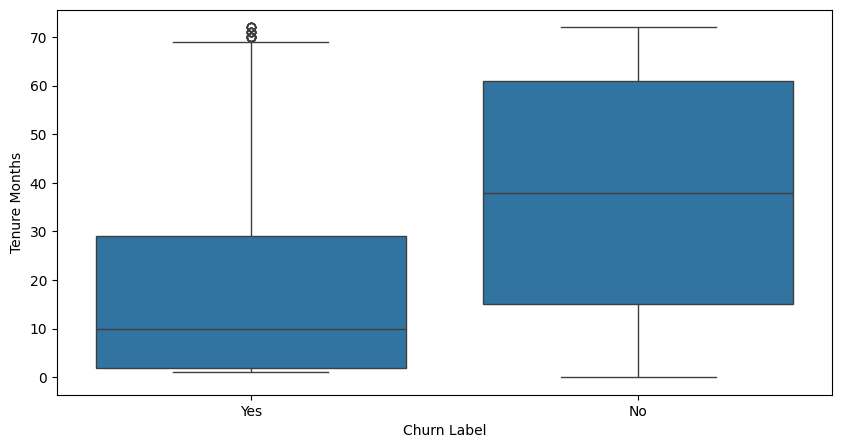

In [248]:
plt.figure(figsize=(10,5))
sns.boxplot(x= 'Churn Label', y= 'Tenure Months', data = df)
plt.show

In [249]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])


,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [250]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


<function matplotlib.pyplot.show(close=None, block=None)>

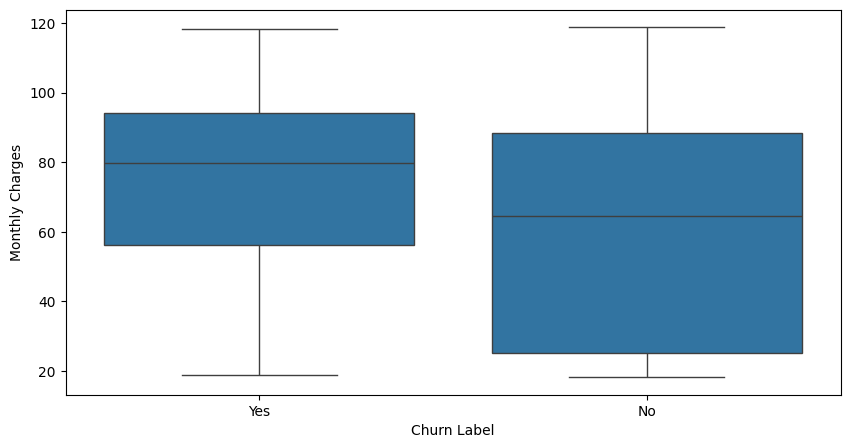

In [251]:
plt.figure(figsize=(10,5))
sns.boxplot(x= 'Churn Label', y= 'Monthly Charges', data = df)
plt.show

In [252]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [253]:
df['Contract'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Contract
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


<function matplotlib.pyplot.show(close=None, block=None)>

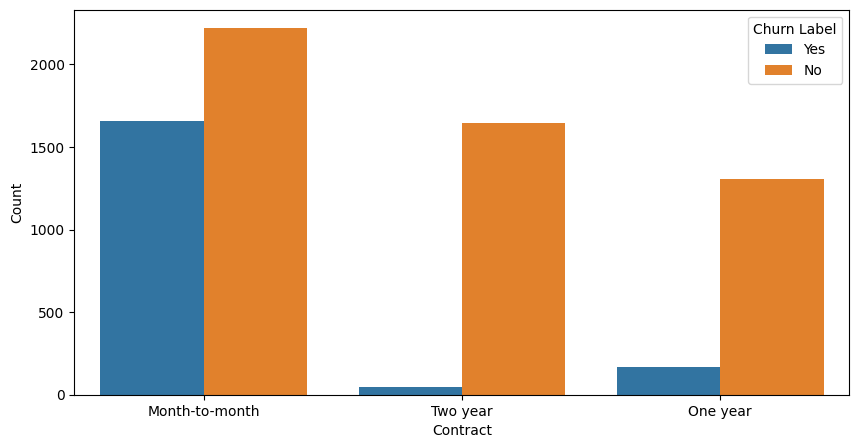

In [254]:
plt.figure(figsize=(10,5))
sns.countplot(x= 'Contract',hue = 'Churn Label', data = df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.show

In [255]:
df['Internet Service'].unique()


array(['DSL', 'Fiber optic', 'No'], dtype=object)

<function matplotlib.pyplot.show(close=None, block=None)>

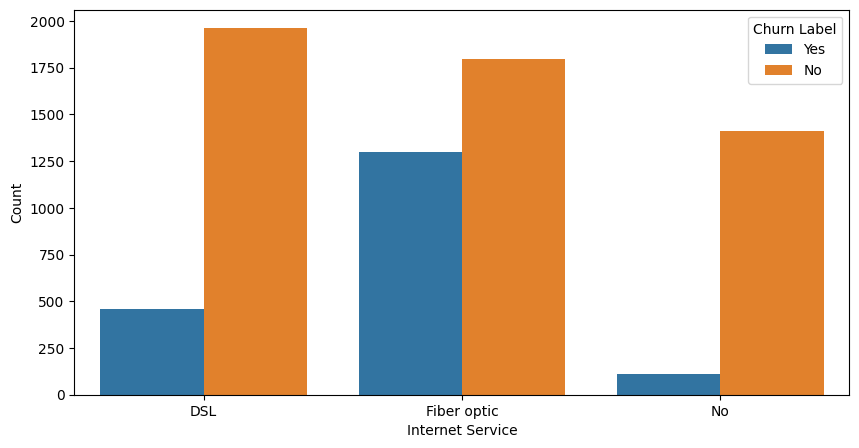

In [256]:
plt.figure(figsize=(10,5))
sns.countplot(x= 'Internet Service',hue = 'Churn Label', data = df)
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show

In [257]:
df['Payment Method'].value_counts()

,count
Payment Method,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


<function matplotlib.pyplot.show(close=None, block=None)>

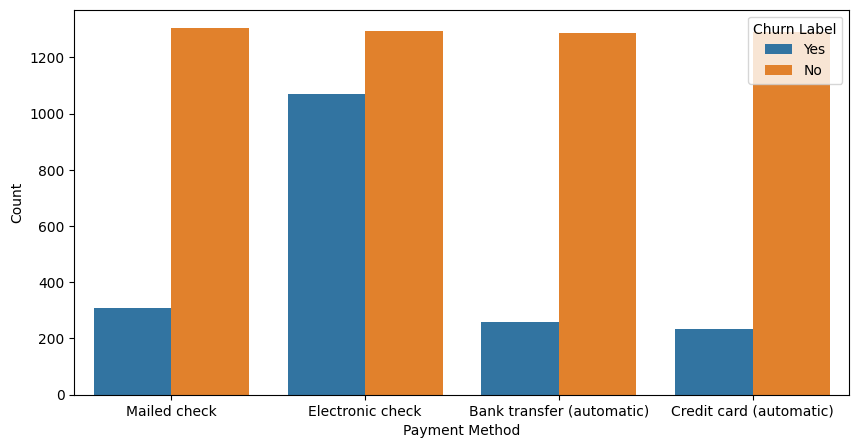

In [258]:
plt.figure(figsize=(10,5))
sns.countplot(x= 'Payment Method',hue = 'Churn Label', data = df)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show

In [259]:
df['Tech Support'].value_counts()

,count
Tech Support,
No,3473
Yes,2044
No internet service,1526


In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

<function matplotlib.pyplot.show(close=None, block=None)>

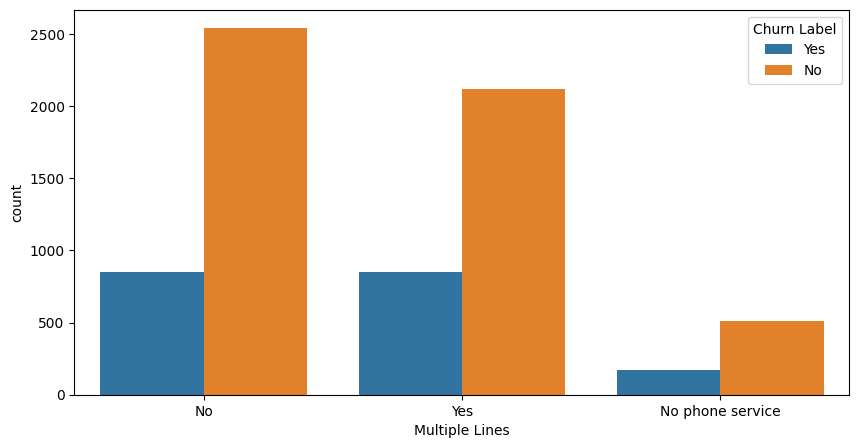

In [261]:
plt.figure(figsize=(10,5))
sns.countplot(x ='Multiple Lines' , hue= 'Churn Label' , data = df)
plt.show

This shows that people not with multiple lines connected stay/Not churn with the company.

<function matplotlib.pyplot.show(close=None, block=None)>

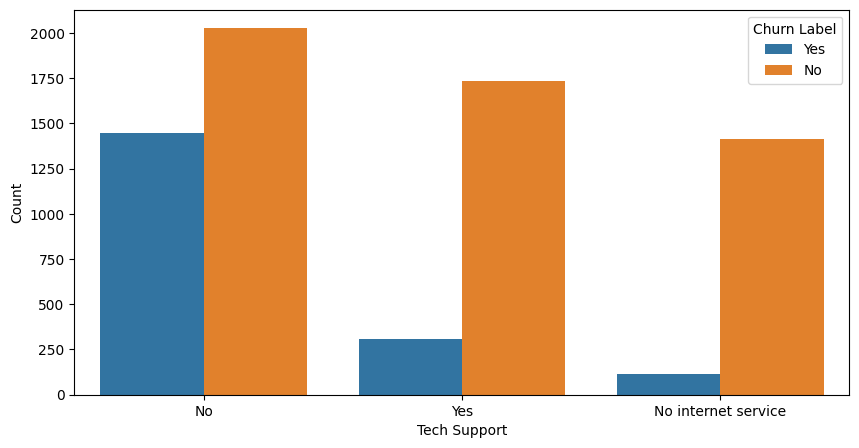

In [262]:
plt.figure(figsize=(10,5))
sns.countplot(x= 'Tech Support',hue = 'Churn Label', data = df)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show

In [263]:
avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()

In [264]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


<function matplotlib.pyplot.show(close=None, block=None)>

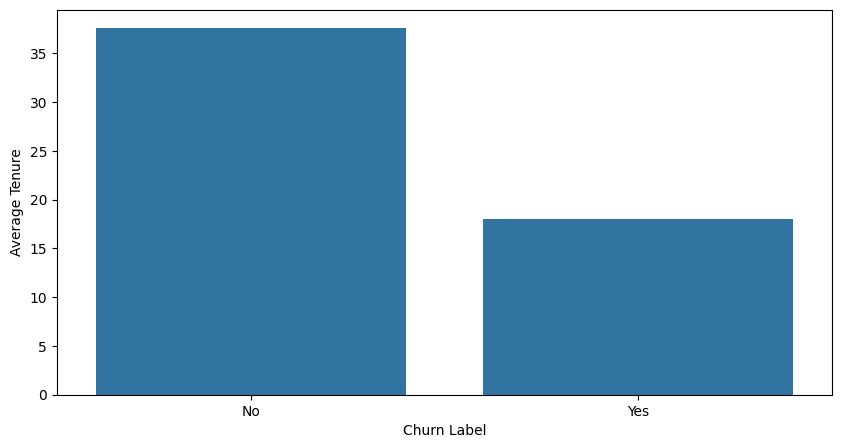

In [265]:
plt.figure(figsize=(10,5))
sns.barplot(x= avg_tenure.index, y= avg_tenure.values)
plt.xlabel('Churn Label')
plt.ylabel('Average Tenure')
plt.show

In [266]:
col_names = ['Monthly Charges', 'Tenure Months', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[col_names].corr()

In [267]:
correlation_matrix

,Monthly Charges,Tenure Months,Churn Value,Churn Score,CLTV
Monthly Charges,1.000000,0.247900,0.193356,0.133754,0.098693
Tenure Months,0.247900,1.000000,-0.352229,-0.224987,0.396406
Churn Value,0.193356,-0.352229,1.000000,0.664897,-0.127463
Churn Score,0.133754,-0.224987,0.664897,1.000000,-0.079782
CLTV,0.098693,0.396406,-0.127463,-0.079782,1.000000


In [268]:
pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**DATA CLEANING**
(Missing values,
Duplicate values,
Encodiing values)

In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [270]:
df['Total Charges'].dtype

dtype('O')

### Data Cleaning: Correcting `Total Charges`

The `Total Charges` column is currently stored as an `object` type (string), which can cause issues with numerical operations and lead to excessive columns if one-hot encoded. We need to convert it to a numeric type. Some entries might be non-numeric (e.g., empty strings for new customers), so we'll coerce errors to `NaN` and then fill these `NaN` values with `0`.

In [271]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
# Fill NaN values (likely from new customers with 0 total charges) with 0
df['Total Charges'] = df['Total Charges'].fillna(0)

print("Data type of 'Total Charges' after conversion:")
print(df['Total Charges'].dtype)

Data type of 'Total Charges' after conversion:
float64


In [272]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [273]:
drop_columns = ['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV']

In [274]:
df = df.drop(columns = drop_columns)

In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

*Dropping City column as well*

In [276]:
df['City']
#if we have not removed city column from here then it would have increased a large no. of rows

,City
0,Los Angeles
1,Los Angeles
2,Los Angeles
3,Los Angeles
4,Los Angeles
...,...
7038,Landers
7039,Adelanto
7040,Amboy
7041,Angelus Oaks


In [277]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.shape

(7043, 1178)

In [278]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [279]:
df.drop(columns = 'City',axis = 1, inplace = True)

### Data Cleaning: Handling `Churn Reason`

The `Churn Reason` column has a significant number of missing values and can have many unique text entries, making it unsuitable for direct one-hot encoding if the goal is to reduce dimensionality. Since it's a reason and not a primary feature for prediction in this context, it's best to drop this column.

In [280]:
df = df.drop(columns=['Churn Reason'])
print("Shape of DataFrame after dropping 'Churn Reason':", df.shape)

Shape of DataFrame after dropping 'Churn Reason': (7043, 20)


### Re-encoding the DataFrame

Now that `Total Charges` is numeric and `Churn Reason` has been dropped, we can re-apply `pd.get_dummies` to create `df_encoded` with a significantly reduced and more appropriate number of columns.

In [281]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [282]:
print(f"New shape of df_encoded: {df_encoded.shape}")

New shape of df_encoded: (7043, 31)


In [283]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [284]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [285]:
df_encoded.shape

(7043, 31)

In [286]:
x = df_encoded.drop(columns = ['Churn Value'])
y = df_encoded['Churn Value']
df_encoded.shape

(7043, 31)



```
`# This is formatted as code`
```

**Train test data split**

```
X_train X_test, Y_train, Y_Test = train_test_spilt(X,Y,test_size = 0.2 random_state = 42)
```



In [287]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [288]:
X_train.shape

(5634, 30)

In [289]:
X_test.shape


(1409, 30)

In [290]:
Y_train.shape

(5634,)

In [291]:
Y_test.shape

(1409,)

Random Forest Implementation

In [292]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [293]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [294]:
y_pred = rf_model.predict(X_test)

In [295]:
y_pred.dtype

dtype('int64')

In [296]:
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7856635911994322


In [297]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)

In [298]:
print(cm)

[[902 107]
 [195 205]]


In [299]:
from sklearn import metrics
print(metrics.classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach1 - Handle Class Imbalance (for improving recall and acurracy to an extent)**

In [300]:
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [301]:
y_pred_balanced = rf_balanced.predict(X_test)

In [302]:
accuracy_balanced = accuracy_score(Y_test, y_pred_balanced)
print(f"Balanced Accuracy: {accuracy_balanced}")

Balanced Accuracy: 0.7920511000709723


In [303]:
cm_balanced = confusion_matrix(Y_test, y_pred_balanced)
print(cm_balanced)

[[907 102]
 [191 209]]


In [304]:
from sklearn import metrics
print(metrics.classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 2 - Hyperparameter tuning**

In [305]:
rf_tuned = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10, min_samples_split=5)
rf_tuned.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=300, random_state=42)

In [306]:
y_pred_tuned = rf_tuned.predict(X_test)
print(classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



### Feature Selection using Random Forest Importance

To improve model efficiency and reduce the number of columns, we can use the `feature_importances_` attribute of our trained `RandomForestClassifier`. This will show us which features contributed most to the model's decision-making process.

We'll then select a subset of these features based on their importance.

In [307]:
# Get feature importances from the tuned Random Forest model
feature_importances = rf_tuned.feature_importances_

# Create a Series for better handling and sorting
features_df = pd.Series(feature_importances, index=X_train.columns).sort_values(ascending=False)

print("Top 10 Feature Importances:")
print(features_df.head(10))

Top 10 Feature Importances:
Tenure Months                      0.178416
Total Charges                      0.132947
Contract_Two year                  0.107709
Monthly Charges                    0.092694
Dependents_Yes                     0.071582
Internet Service_Fiber optic       0.060134
Payment Method_Electronic check    0.047012
Contract_One year                  0.037609
Online Security_Yes                0.029286
Tech Support_Yes                   0.021814
dtype: float64


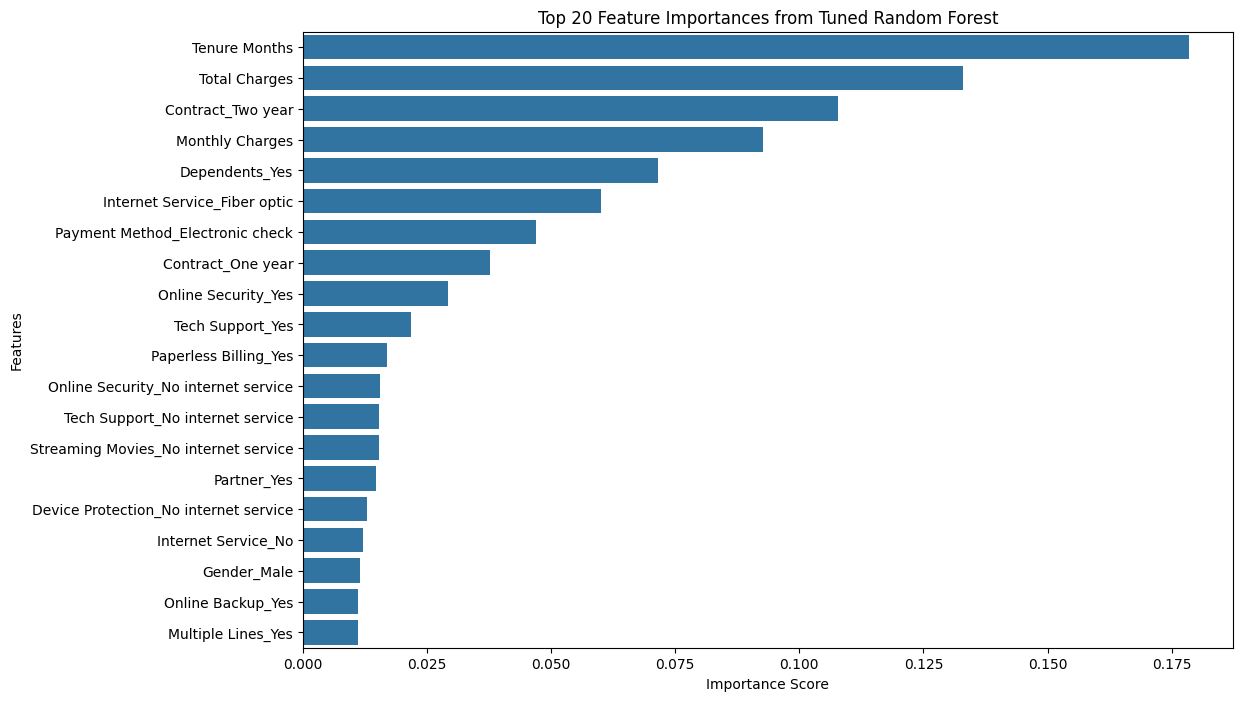

In [308]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=features_df.head(20).values, y=features_df.head(20).index)
plt.title('Top 20 Feature Importances from Tuned Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Selecting Top Features and Retraining the Model

Based on the feature importances, we can now select a subset of the most important features. For demonstration, let's select the top 15 features. You can adjust this number based on your specific requirements for efficiency and performance trade-offs.

Then, we'll retrain the Random Forest model with this reduced feature set and evaluate its performance.

In [309]:
# Selecting top N features
selected_features = features_df.head(10).index.tolist()

# Create new training and testing sets with only selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after selection: {X_train_selected.shape[1]}")

# Retrain the model with selected features
rf_selected = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', max_depth=10, min_samples_split=5)
rf_selected.fit(X_train_selected, Y_train)

# Make predictions and evaluate
y_pred_selected = rf_selected.predict(X_test_selected)
print("\nClassification Report with Selected Features:")
print(classification_report(Y_test, y_pred_selected))

accuracy_selected = accuracy_score(Y_test, y_pred_selected)
print(f"Accuracy with Selected Features: {accuracy_selected}")

Original number of features: 30
Number of features after selection: 10

Classification Report with Selected Features:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1009
           1       0.58      0.78      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.81      0.78      0.78      1409

Accuracy with Selected Features: 0.7757274662881476


### Adjusting Classification Threshold for Improved Recall ###

Let's re-evaluate the model's performance (recall and precision) across a range of thresholds, using the probabilities from the model trained with BorderlineSMOTE. This will help us find a threshold that meets your target recall and precision.

,Threshold,Recall (Churn),Precision (Churn)
0,0.10,0.9725,0.389780
1,0.15,0.9500,0.410811
2,0.20,0.9325,0.434226
3,0.25,0.9125,0.466752
4,0.30,0.8850,0.488276
5,0.35,0.8525,0.510479
6,0.40,0.8175,0.526570
7,0.45,0.7950,0.551127
8,0.50,0.7800,0.577778
9,0.55,0.7150,0.600840


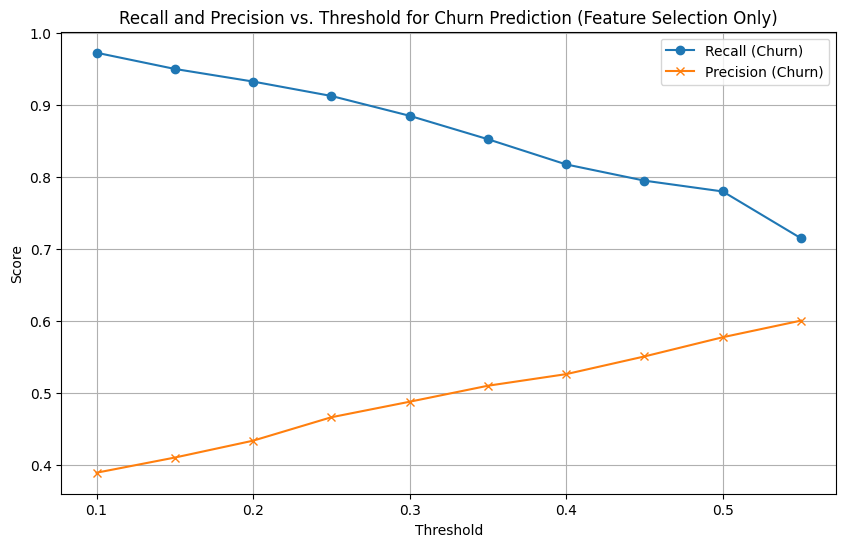

In [310]:
from sklearn.metrics import precision_score, recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (churn = 1) from the model trained with selected features
y_pred_proba_selected = rf_selected.predict_proba(X_test_selected)[:, 1]

thresholds = np.arange(0.1, 0.6, 0.05) # Test thresholds from 0.1 to 0.55

results_selected = []
for threshold in thresholds:
    y_pred_threshold_selected = (y_pred_proba_selected >= threshold).astype(int)
    recall = recall_score(Y_test, y_pred_threshold_selected)
    precision = precision_score(Y_test, y_pred_threshold_selected)
    results_selected.append({'Threshold': threshold, 'Recall (Churn)': recall, 'Precision (Churn)': precision})

results_df_selected = pd.DataFrame(results_selected)
display(results_df_selected)

# Plotting Recall and Precision vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(results_df_selected['Threshold'], results_df_selected['Recall (Churn)'], label='Recall (Churn)', marker='o')
plt.plot(results_df_selected['Threshold'], results_df_selected['Precision (Churn)'], label='Precision (Churn)', marker='x')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Recall and Precision vs. Threshold for Churn Prediction (Feature Selection Only)')
plt.legend()
plt.grid(True)
plt.show()

### Selecting an Optimal Threshold based on Recall and Precision Constraints with selcted features ###
Find thresholds that meet your criteria: at least **80% recall** for churn prediction, while maintaining a **minimum precision of 55%**.

In [311]:
# Filter results based on the user's criteria
optimal_thresholds_selected = results_df_selected[(results_df_selected['Recall (Churn)'] >= 0.80) & (results_df_selected['Precision (Churn)'] >= 0.55)]

if not optimal_thresholds_selected.empty:
    print("Thresholds meeting both criteria (Recall >= 0.80, Precision >= 0.55) with Feature Selection Only:")
    display(optimal_thresholds_selected)

    if len(optimal_thresholds_selected) > 1:
        # Recommend the threshold with the highest precision among those that meet the recall target.
        best_threshold_selected = optimal_thresholds_selected.loc[optimal_thresholds_selected['Precision (Churn)'].idxmax()]
        print(f"\nRecommended threshold (highest precision while meeting recall target): {best_threshold_selected['Threshold']:.2f}")
        print(f"  Recall: {best_threshold_selected['Recall (Churn)']:.2f}")
        print(f"  Precision: {best_threshold_selected['Precision (Churn)']:.2f}")
    else:
        print("\nOnly one threshold meets the criteria. This is your best option for now.")
else:
    print("No threshold found that meets both criteria (Recall >= 0.80 AND Precision >= 0.55) with Feature Selection Only.")
    print("You may need to reconsider one of your targets or explore further model improvements.")

No threshold found that meets both criteria (Recall >= 0.80 AND Precision >= 0.55) with Feature Selection Only.
You may need to reconsider one of your targets or explore further model improvements.


**Threshold = .5** gives us the optimum value of recall = .78 and precision = .55, precision shouldn't be cost to gain high recall, but if cost of retention per customer is very less than cost lost for loosing per customer then we can decrease the threshold values.

### SHAP Analysis for Model Interpretability

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations by using Shapley values from cooperative game theory. This helps us understand how each feature contributes to the prediction of the `rf_selected` model.

In [313]:
!pip install shap
import shap

# Initialize Javascript for SHAP plots
shap.initjs()

# Create a SHAP explainer for the rf_selected model
# Using `predict_proba` for classification models
explainer = shap.TreeExplainer(rf_selected)

# Calculate SHAP values for the test set using the NumPy array values
# This might take a moment depending on the size of X_test_selected
shap_values = explainer.shap_values(X_test_selected.values)

### SHAP Summary Plot

The summary plot combines feature importance with feature effects. Each point on the plot is a Shapley value for a feature and an instance. The position on the y-axis is determined by the feature, and the x-axis position is the Shapley value. The color represents the feature's value (red for high, blue for low). Overlapping points are stacked, creating a density plot.

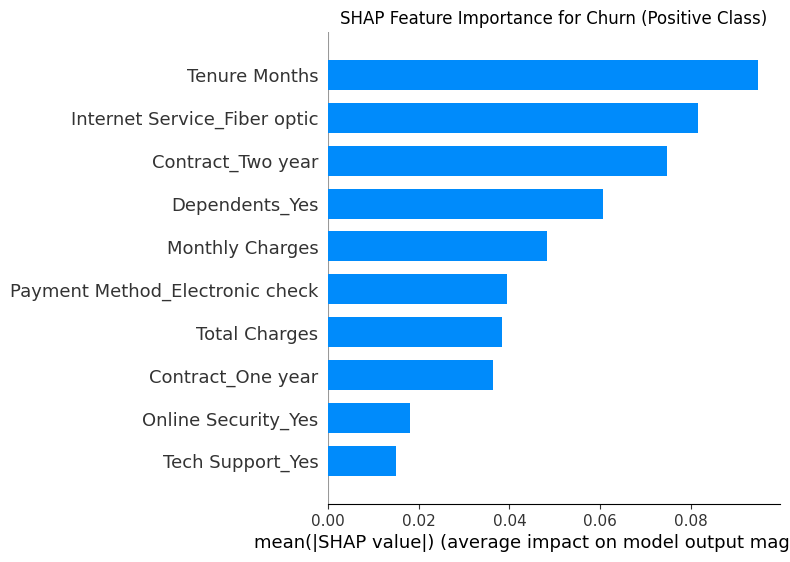

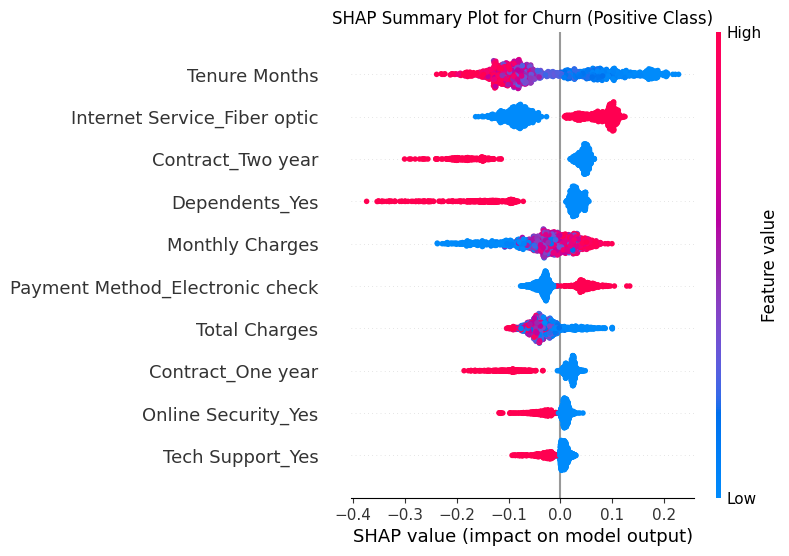

In [314]:
# Generate a SHAP summary plot for the positive class (churn = 1)
# We use shap_values[:, :, 1] because it corresponds to the positive class predictions in the 3D array structure
# Pass X_test_selected.values to ensure compatibility and provide feature_names explicitly
shap.summary_plot(shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, plot_type="bar", show=False)
plt.title('SHAP Feature Importance for Churn (Positive Class)')
plt.show()

# More detailed summary plot (beeswarm plot)
shap.summary_plot(shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, show=False)
plt.title('SHAP Summary Plot for Churn (Positive Class)')
plt.show()

### SHAP Dependence Plots for Top 5 Features



In [316]:
top_5_features = features_df.head(5).index.tolist()

print(f"Top 5 features for SHAP dependence plots: {top_5_features}")

Top 5 features for SHAP dependence plots: ['Tenure Months', 'Total Charges', 'Contract_Two year', 'Monthly Charges', 'Dependents_Yes']


#### 1. SHAP Dependence Plot for 'Tenure Months'

This plot shows how the number of months a customer has stayed with the company influences the churn prediction.

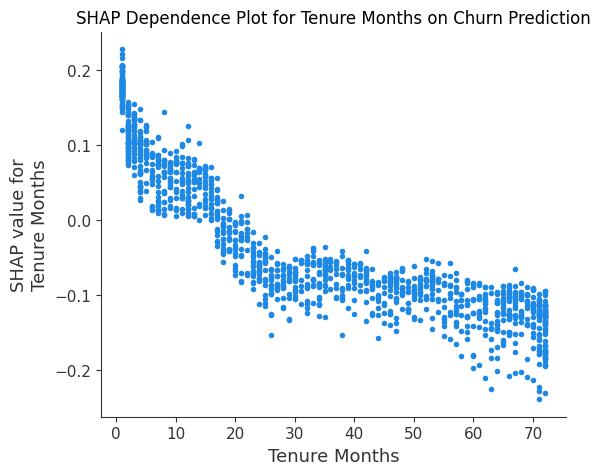

In [317]:
# SHAP dependence plot for 'Tenure Months'
shap.dependence_plot("Tenure Months", shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, interaction_index=None, show=False)
plt.title('SHAP Dependence Plot for Tenure Months on Churn Prediction')
plt.show()

#### 2. SHAP Dependence Plot for 'Total Charges'

This plot illustrates how the total amount charged to a customer influences the churn prediction.

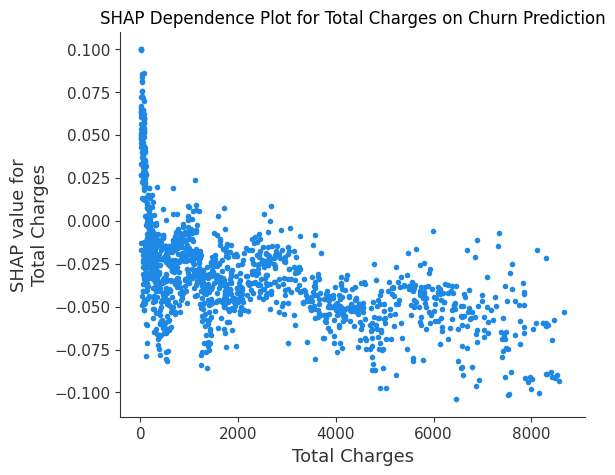

In [318]:
# SHAP dependence plot for 'Total Charges'
shap.dependence_plot("Total Charges", shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, interaction_index=None, show=False)
plt.title('SHAP Dependence Plot for Total Charges on Churn Prediction')
plt.show()

#### 3. SHAP Dependence Plot for 'Contract_Two year'

This plot shows the impact of having a two-year contract on the churn prediction.

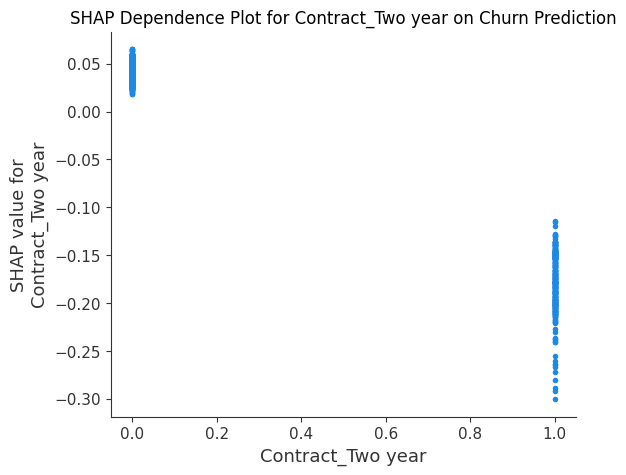

In [319]:
# SHAP dependence plot for 'Contract_Two year'
shap.dependence_plot("Contract_Two year", shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, interaction_index=None, show=False)
plt.title('SHAP Dependence Plot for Contract_Two year on Churn Prediction')
plt.show()

#### 4. SHAP Dependence Plot for 'Monthly Charges'

This plot visualizes how the monthly charges affect the churn prediction.

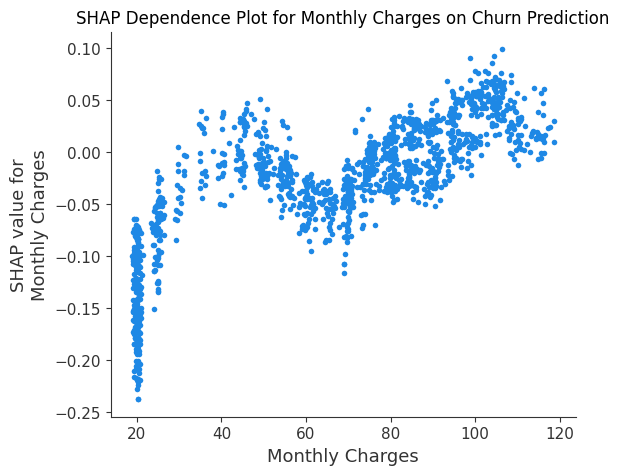

In [320]:
# SHAP dependence plot for 'Monthly Charges'
shap.dependence_plot("Monthly Charges", shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, interaction_index=None, show=False)
plt.title('SHAP Dependence Plot for Monthly Charges on Churn Prediction')
plt.show()

#### 5. SHAP Dependence Plot for 'Dependents_Yes'

This plot shows the influence of whether a customer has dependents on the churn prediction.

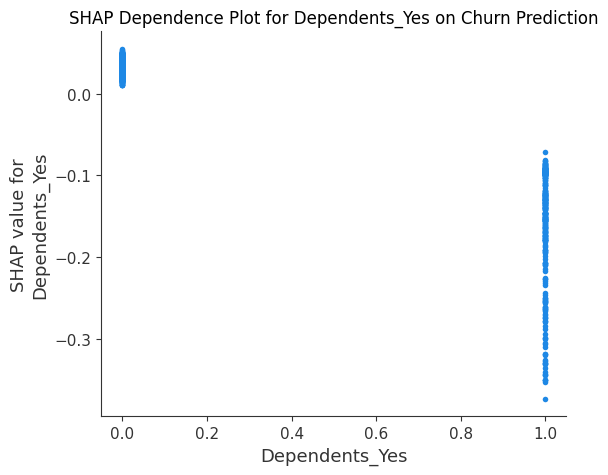

In [321]:
# SHAP dependence plot for 'Dependents_Yes'
shap.dependence_plot("Dependents_Yes", shap_values[:, :, 1], X_test_selected.values, feature_names=X_test_selected.columns, interaction_index=None, show=False)
plt.title('SHAP Dependence Plot for Dependents_Yes on Churn Prediction')
plt.show()